In [2]:
# %%
import matplotlib.pyplot as plt
import numpy as np
from qutip import spin_Jx, spin_Jy, spin_Jz, spin_coherent
from scipy.optimize import minimize, least_squares
from joblib import Parallel, delayed
import time as t
from scipy.linalg import sqrtm, inv, eigh, expm, expm_frechet
import math
import gc
import argparse
import os


In [3]:

# %%
# parser = argparse.ArgumentParser()
# parser.add_argument("--outdir", type=str)
# args = parser.parse_args()
# os.makedirs(args.outdir, exist_ok=True)

#Parameters
rng = np.random.default_rng(3)
J = 1 #Spin of system
dim = int(2*J+1)
t_steps = 1000 #Number of Trotter steps to simulate
delta_t = 0.001 #Time step for Trotter evolution
w_stdev = 0.01 #Standard deviation of true parameter values (for random generation)
#w_true = rng.normal(0, w_stdev, size=3) #True parameter values
w_true = np.array([40.02, 12.53, 23.75])
w_init = [30, 0, 6] #Initial guess for parameters
batch_size = 1 #Number of parallel optimizations
iter = 1 #Total number of optimization iterations
theta_scs = np.array([0, np.pi/2]) #Initial spin coherent state parameters (theta values)
phi_scs = np.array([0, np.pi/2]) #Initial spin coherent state parameters (phi values)
init_rhos = [spin_coherent(J, theta, phi, type = 'dm').full() for theta, phi in zip(theta_scs, phi_scs)]
n_states = len(init_rhos)
steps_per_state = t_steps // n_states
#measurement_steps_array = np.logspace(1, np.log10(steps_per_state), num=10, dtype=int) #Array of different numbers of measurements to simulate
measurement_steps_array = np.array([48]) #Array of different numbers of measurements to simulate
G = 8.9e-7 #Rotation sensitivity in radians per Hz
N_a = 2e5 #Number of atoms in ensemble
J_x = spin_Jx(J).full()
J_y = spin_Jy(J).full()
J_z = spin_Jz(J).full()
J_z2 = J_z @ J_z
obs_0 = J_z #Initial observable
folder = "/users/agarcia2001/data_trotter_least_squares_1" #Folder to save results

if np.array_equal(obs_0, J_x):
    obs_0_string = 'J_x'
elif np.array_equal(obs_0, J_y):
    obs_0_string = 'J_y'
elif np.array_equal(obs_0, J_z):
    obs_0_string = 'J_z'
else:
    obs_0_string = 'unknown'

def random_bloch_directions(N):
    phi = rng.uniform(0, 2*np.pi, N)
    u = rng.uniform(-1, 1, N)
    theta = np.arccos(u)
    return theta, phi

def fibonacci_sphere(N):
    i = np.arange(N)
    phi = 2 * np.pi * (i / ((1 + np.sqrt(5)) / 2) % 1)
    z = 1 - 2*(i + 0.5)/N
    theta = np.arccos(z)
    return theta, phi


def commutator(A, B):
   """Compute the commutator [A, B] = AB - BA."""
   return A @ B - B @ A

def expect(obs, state):
    """Compute the expectation value of an observable."""
    return np.real(np.trace(obs @ state))

def fidelity(rho, sigma):
    # Compute sqrt(rho)
    sqrt_rho = sqrtm(rho)
    # Compute sqrt_rho * sigma * sqrt_rho
    inner = sqrt_rho @ sigma @ sqrt_rho
    # Compute sqrt of the inner matrix
    sqrt_inner = sqrtm(inner)
    # Take the trace and square the result
    fidelity_value = np.real(np.trace(sqrt_inner)) ** 2
    return fidelity_value

def compute_expectations(w, init_rhos):
    H_w = w[0]*J_x + w[1]*J_y + w[2]*J_z
    U = expm(-1j * delta_t * H_w)
    U_dag = U.conj().transpose()

    # Frechet derivatives of U
    delU_x = expm_frechet(-1j * delta_t * H_w, -1j * delta_t * J_x, compute_expm=False)
    delU_y = expm_frechet(-1j * delta_t * H_w, -1j * delta_t * J_y, compute_expm=False)
    delU_z = expm_frechet(-1j * delta_t * H_w, -1j * delta_t * J_z, compute_expm=False)

    # Derivatives of U^\dagger
    delUdag_x = delU_x.conj().transpose()
    delUdag_y = delU_y.conj().transpose()
    delUdag_z = delU_z.conj().transpose()

    n_states = len(init_rhos)
    steps_per_state = t_steps // n_states

    expectation = []
    del_expect_x = []
    del_expect_y = []
    del_expect_z = []

    for rho0 in init_rhos:
        rho = rho0.copy()

        del_rho_x = np.zeros_like(rho)
        del_rho_y = np.zeros_like(rho)
        del_rho_z = np.zeros_like(rho)

        for _ in range(steps_per_state):
            if _ in measurement_indices:
                expectation.append(expect(obs_0, rho))
                del_expect_x.append(expect(obs_0, del_rho_x))
                del_expect_y.append(expect(obs_0, del_rho_y))
                del_expect_z.append(expect(obs_0, del_rho_z))
            

            rho_new = U @ rho @ U_dag

            del_rho_x_new = (
                delU_x @ rho @ U_dag
                + U @ del_rho_x @ U_dag
                + U @ rho @ delUdag_x
            )

            del_rho_y_new = (
                delU_y @ rho @ U_dag
                + U @ del_rho_y @ U_dag
                + U @ rho @ delUdag_y
            )

            del_rho_z_new = (
                delU_z @ rho @ U_dag
                + U @ del_rho_z @ U_dag
                + U @ rho @ delUdag_z
            )

            rho = rho_new
            del_rho_x = del_rho_x_new
            del_rho_y = del_rho_y_new
            del_rho_z = del_rho_z_new

    return expectation, del_expect_x, del_expect_y, del_expect_z

def residuals(w, M_vec, init_rhos):
    H_w = w[0]*J_x + w[1]*J_y + w[2]*J_z
    U = expm(-1j * delta_t * H_w)
    U_dag = U.conj().transpose()
    expectation = []
    n_states = len(init_rhos)
    steps_per_state = t_steps // n_states

    for rho0 in init_rhos:
        rho = rho0.copy()

        for _ in range(steps_per_state):
            if _ in measurement_indices:
                expectation.append(expect(obs_0, rho))
            rho_new = U @ rho @ U_dag
            rho = rho_new
    return M_vec - expectation


def w_estimate(gaussian_noise, expectation, w_init, init_rhos):
    M_vec = expectation + gaussian_noise
    optimization = least_squares(residuals, x0=w_init, args=(M_vec, init_rhos), method='lm')
    return optimization



In [4]:

# %%
runs = len(measurement_steps_array)
runtime_array = np.zeros(runs)
covar_array = [None] * runs
mean_array = [None] * runs
std_array = [None] * runs
fisher_array = [None] * runs
w_est_all_runs = [None] * runs
w_est_dict_failures = [None] * runs
bias = [None] * runs
CRB_diff_eig = [None] * runs
fisher_shannon_entropy = [None] * runs

for k in range(runs):
    start_time = t.time()
    shannon = []
    w_est = []
    failures = []
    #theta_scs, phi_scs = random_bloch_directions(N_intial_states[k])
    #theta_scs, phi_scs = fibonacci_sphere(N_intial_states[k])
    measurement_steps = measurement_steps_array[k]
    measurement_indices = np.linspace(0, steps_per_state-1, measurement_steps, dtype=int)
    N_p = 9.6e8 / (measurement_steps*n_states) #Number of photons per measurement pulse
    sn_sd = 1/(np.sqrt(N_p)*G*N_a)
    #Calculate expectation value
    expectation, del_expect_x, del_expect_y, del_expect_z = compute_expectations(w_true, init_rhos)
    
    #Calculate fisher information matrix and shannon entropy
    # for j in np.arange(0, t_steps+1, 10):
    #     del_expectation_x = del_expect_x[:j]
    #     del_expectation_y = del_expect_y[:j]
    #     del_expectation_z = del_expect_z[:j]
    #     fisher_matrix = np.zeros((3, 3))
    #     fisher_matrix[0, 0] = np.vdot(del_expectation_x, del_expectation_x) / sn_sd**2
    #     fisher_matrix[1, 1] = np.vdot(del_expectation_y, del_expectation_y) / sn_sd**2
    #     fisher_matrix[2, 2] = np.vdot(del_expectation_z, del_expectation_z) / sn_sd**2
    #     fisher_matrix[0, 1] = np.vdot(del_expectation_x, del_expectation_y) / sn_sd**2
    #     fisher_matrix[0, 2] = np.vdot(del_expectation_x, del_expectation_z) / sn_sd**2
    #     fisher_matrix[1, 2] = np.vdot(del_expectation_y, del_expectation_z) / sn_sd**2
    #     fisher_matrix[1, 0] = fisher_matrix[0, 1]
    #     fisher_matrix[2, 0] = fisher_matrix[0, 2]
    #     fisher_matrix[2, 1] = fisher_matrix[1, 2]
    #     fisher_eig = np.linalg.eigvals(fisher_matrix)
    #     fisher_eig = fisher_eig/np.sum(fisher_eig)
    #     shannon.append(-np.sum(fisher_eig * np.log(fisher_eig)))
    # fisher_shannon_entropy[k] = np.array(shannon)
    fisher_matrix = np.zeros((3, 3))
    fisher_matrix[0, 0] = np.vdot(del_expect_x, del_expect_x) / sn_sd**2
    fisher_matrix[1, 1] = np.vdot(del_expect_y, del_expect_y) / sn_sd**2
    fisher_matrix[2, 2] = np.vdot(del_expect_z, del_expect_z) / sn_sd**2
    fisher_matrix[0, 1] = np.vdot(del_expect_x, del_expect_y) / sn_sd**2
    fisher_matrix[0, 2] = np.vdot(del_expect_x, del_expect_z) / sn_sd**2
    fisher_matrix[1, 2] = np.vdot(del_expect_y, del_expect_z) / sn_sd**2
    fisher_matrix[1, 0] = fisher_matrix[0, 1]
    fisher_matrix[2, 0] = fisher_matrix[0, 2]
    fisher_matrix[2, 1] = fisher_matrix[1, 2]
    fisher_array[k] = fisher_matrix

    while(len(w_est) < iter):
        noise = [rng.normal(0, sn_sd, measurement_steps*n_states) for _ in range(batch_size)]
        w_est_dict = Parallel(n_jobs=-1)(delayed(w_estimate)(gaussian_noise = n, expectation = expectation, w_init = w_init, init_rhos = init_rhos) for n in noise)
        #failures.extend([res for res in w_est_dict if not res.success])
        successes = [res.x for res in w_est_dict if res.success]
        w_est.extend(successes)
    #w_est_dict_failures[k] = failures
    w_est = np.array(w_est[:iter])
    #w_est_all_runs[k] = w_est


In [53]:
w_est_dict[0]

     message: Both `ftol` and `xtol` termination conditions are satisfied.
     success: True
      status: 4
         fun: [ 3.626e-03 -4.542e-03 ... -1.955e-03 -3.023e-03]
           x: [ 4.002e+01  1.252e+01  2.375e+01]
        cost: 0.0001749379428484463
         jac: [[ 0.000e+00  0.000e+00  0.000e+00]
               [ 3.868e-03  1.209e-03 -3.427e-05]
               ...
               [ 7.731e-02  7.028e-03  2.796e-02]
               [-1.062e-01 -4.438e-02 -7.677e-02]]
        grad: [ 1.870e-10 -3.064e-11 -1.875e-10]
  optimality: 1.8750948946213812e-10
 active_mask: [0 0 0]
        nfev: 33
        njev: None

In [8]:
def z_fit(x, w):
    return 1/(w[0]**2 + w[1]**2 + w[2]**2) * (w[2]**2 + (w[0]**2 + w[1]**2)*np.cos(np.sqrt(w[0]**2 + w[1]**2 + w[2]**2)*x))
def z_fit1(x, w):
    return np.cos(np.sqrt(w[0]**2 + w[1]**2 + w[2]**2)*x)

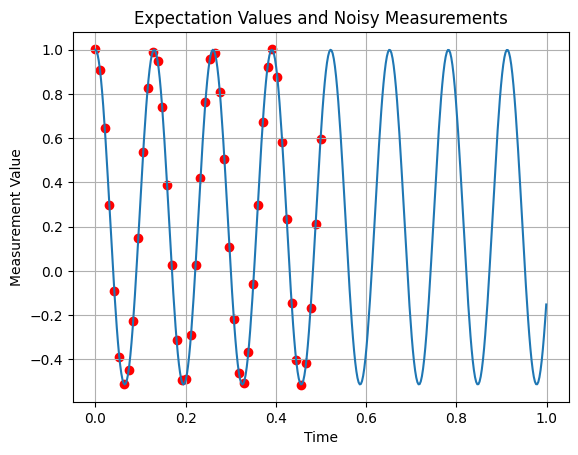

2322.6638000000003


In [14]:
M_vec = expectation + noise[0]
#fun_guess = -w_est_dict[0].fun + M_vec
#time = np.linspace(0, t_steps*delta_t, len(M_vec))
#plt.plot(time, fun_guess, label='Expectation guess')
m = np.linspace(0, t_steps-1, 400)*delta_t
plt.scatter(measurement_indices*delta_t, M_vec[:measurement_steps], color='red', label='Measurements')
#plt.plot(measurement_indices, z_fit(measurement_indices, w_true), label='True expectation')
plt.plot(m, z_fit(m, w_true), label='True expectation')
#plt.plot(m, z_fit1(m, w_true), label='True expectation (simplified)')
plt.xlabel('Time')
plt.ylabel('Measurement Value')
plt.title('Expectation Values and Noisy Measurements')
plt.grid()
plt.show()
print(w_true[0]**2 + w_true[1]**2 + w_true[2]**2)

In [ ]:

   #Calculate covariance and mean of w estimates
    covariance = np.cov(w_est, rowvar=False)
    covar_array[k] = covariance
    mean_array[k] = np.mean(w_est, axis=0)
    bias[k] = mean_array[k] - np.array(w_true)
    std_array[k] = np.diag(covariance)

    end_time = t.time()
    runtime_array[k] = end_time - start_time


In [ ]:

#fisher_shannon_time = delta_t * np.arange(0, t_steps+1, 10)
fisher_inv_array = np.linalg.inv(fisher_array)
fisher_inv_trace = np.trace(fisher_inv_array, axis1=1, axis2=2)
fisher_inv_normalized = fisher_inv_array / fisher_inv_trace[:, None, None]
cov_array_trace = np.trace(covar_array, axis1=1, axis2=2)
cov_array_normalized = covar_array / cov_array_trace[:, None, None]
infidelity_values = np.array([1-fidelity(fisher_inv_normalized[i], cov_array_normalized[i]) for i in range(runs)])
MSE = np.array([[bias[i][k]**2 + std_array[i][k] for k in range(len(w_true))] for i in range(runs)])

for i in range(runs):
    CRB_diff = covar_array[i] - fisher_inv_array[i]
    CRB_diff_eig[i] = np.linalg.eigvals(CRB_diff)



In [ ]:
# noise = rng.normal(0, sn_sd, size=len(expectation))
# M_vec = expectation + noise

# time = np.linspace(0, t_steps*delta_t, len(M_vec))
# plt.plot(time, expectation, label='Expectation')
# plt.scatter(time, M_vec, color='red', label='Measurements')
# plt.xlabel('Time')
# plt.ylabel('Measurement Value')
# plt.title('Expectation Values and Noisy Measurements')
# plt.grid()
# plt.show()

In [ ]:

# %%
parameters = (
    f"Parameters: J = {J}; w = {w_true}; w_stdev = {w_stdev:.3f}; sn_sd = {sn_sd:.3f}; "
    f"delta_t = {delta_t}; t_steps = {t_steps}; iter = {iter}; Initial observable = {obs_0_string}"
)

np.save(f"{folder}/measurement_steps_array.npy", measurement_steps_array)
np.save(f"{folder}/mean_array.npy", mean_array)
#np.save(os.path.join(args.outdir, "N_intial_states.npy"), N_intial_states)
np.save(f"{folder}/bias.npy", bias)
np.save(f"{folder}/std_array.npy", std_array)
np.save(f"{folder}/covar_array.npy", covar_array)
np.save(f"{folder}/fisher.npy", fisher_array)
np.save(f"{folder}/runtime.npy", runtime_array)
#np.save(f"{folder}/w_est_all_runs.npy", np.array(w_est_all_runs))
np.save(f"{folder}/infidelity.npy", infidelity_values)
#np.save(f"{folder}/evolution_time.npy", evolution_time)
np.save(f"{folder}/fisher_inv_trace.npy", fisher_inv_trace)
np.save(f"{folder}/covar_trace.npy", cov_array_trace)
np.save(f"{folder}/CRB_diff_eig.npy", CRB_diff_eig)
#np.save(f"{folder}/fisher_shannon_entropy.npy", fisher_shannon_entropy)
#np.save(f"{folder}/fisher_shannon_time.npy", fisher_shannon_time)
np.save(f"{folder}/MSE.npy", MSE)
with open(f"{folder}/parameters.txt", "w") as f:
    f.write(parameters)
#with open(f"{folder}/w_est_failures.txt", "w") as f:
#    f.write(str(w_est_dict_failures))





# %%



